In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [16]:
df = pd.read_csv('C:/Users/anany/OneDrive/Desktop/ai proj/Customer Churn Prediction/data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [18]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
df.drop(columns=['customerID'], inplace=True)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'Missing TotalCharges after conversion: {df["TotalCharges"].isna().sum()}')

mask = df['TotalCharges'].isna()
df.loc[mask, 'TotalCharges'] = df.loc[mask, 'MonthlyCharges'] * df.loc[mask, 'tenure']
print(f'Missing TotalCharges after imputation: {df["TotalCharges"].isna().sum()}')

Missing TotalCharges after conversion: 11
Missing TotalCharges after imputation: 0


In [20]:
# Check duplicates
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')
if dupes > 0:
    df.drop_duplicates(inplace=True)

Duplicate rows: 22


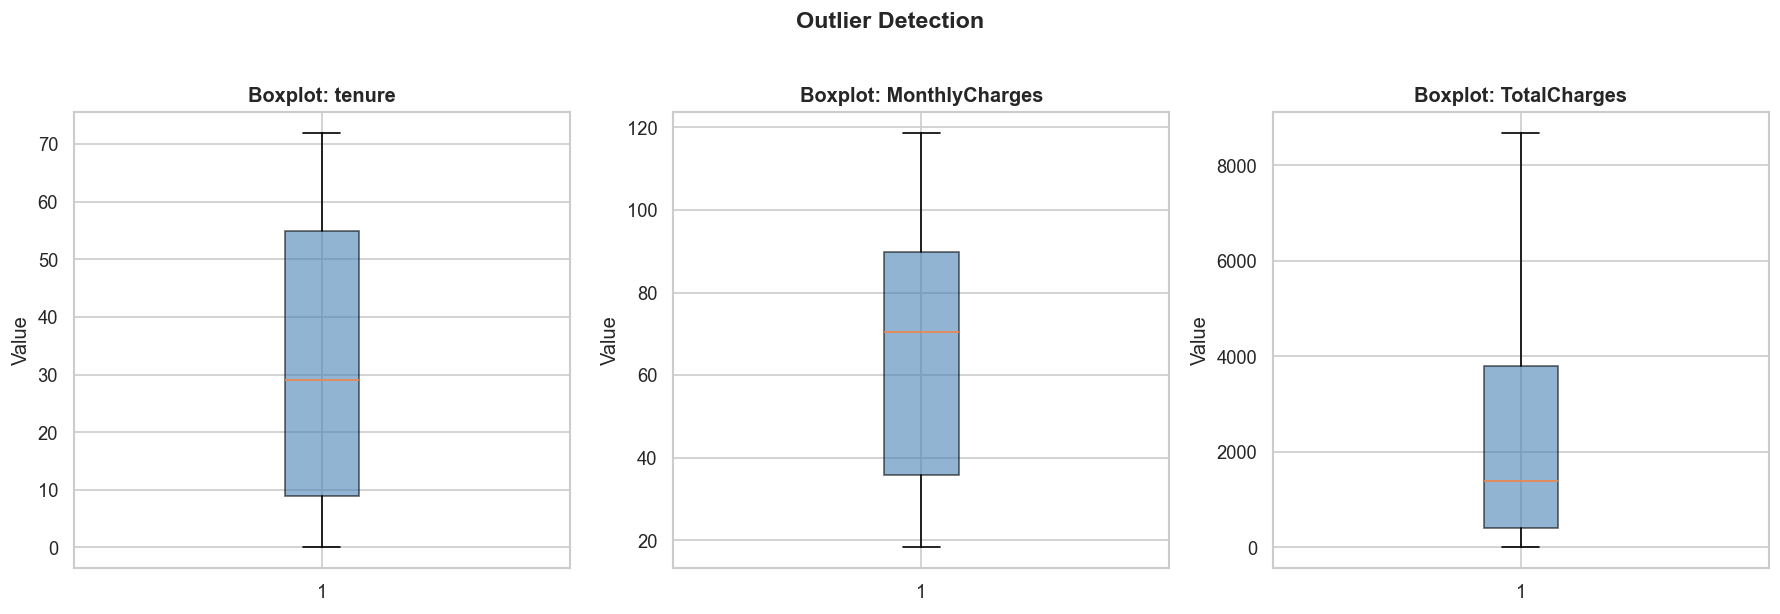

tenure: 0 outliers detected (retained — valid business data)
MonthlyCharges: 0 outliers detected (retained — valid business data)
TotalCharges: 0 outliers detected (retained — valid business data)


In [21]:
# Outlier detection — IQR method on numerical columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Outlier Detection', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f'{col}: {outliers} outliers detected (retained — valid business data)')

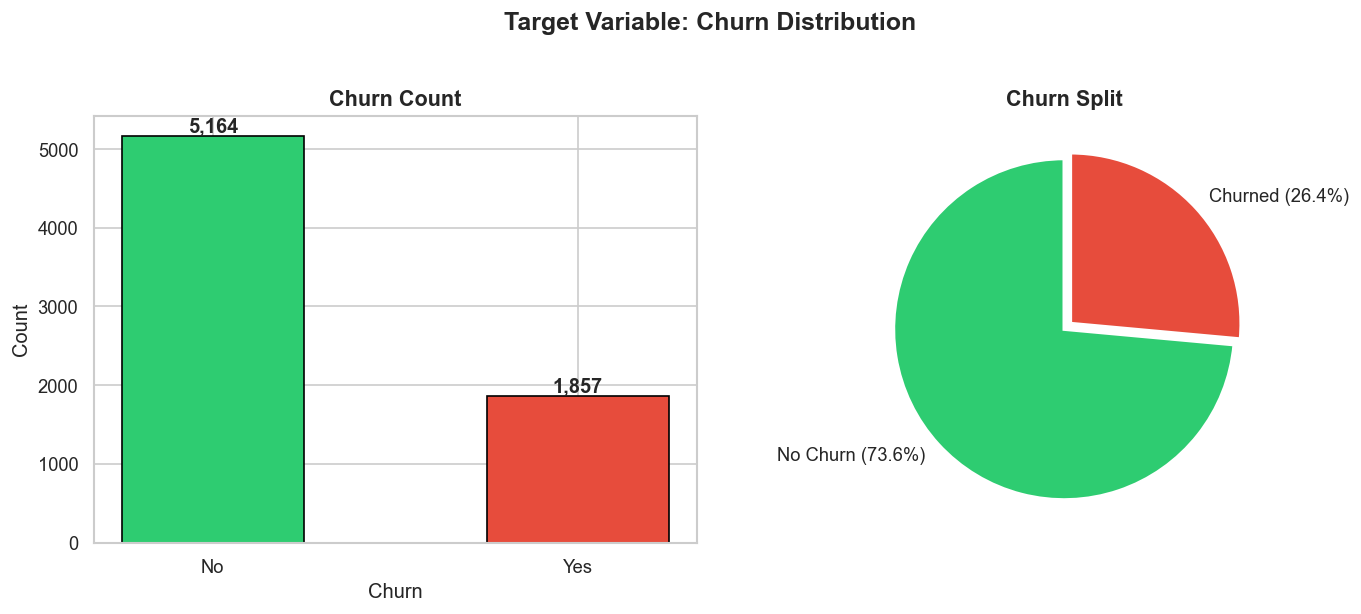

Class imbalance: 26.4% churn vs 73.6% no-churn


In [22]:
# Target variable distribution
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar(churn_counts.index, churn_counts.values,
                    color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Churn Count', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')

axes[1].pie(churn_pct.values,
            labels=[f'No Churn ({churn_pct["No"]:.1f}%)', f'Churned ({churn_pct["Yes"]:.1f}%)'],
            colors=['#2ecc71', '#e74c3c'], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2), explode=(0, 0.05))
axes[1].set_title('Churn Split', fontweight='bold', fontsize=13)

plt.suptitle('Target Variable: Churn Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Class imbalance: {churn_pct["Yes"]:.1f}% churn vs {churn_pct["No"]:.1f}% no-churn')

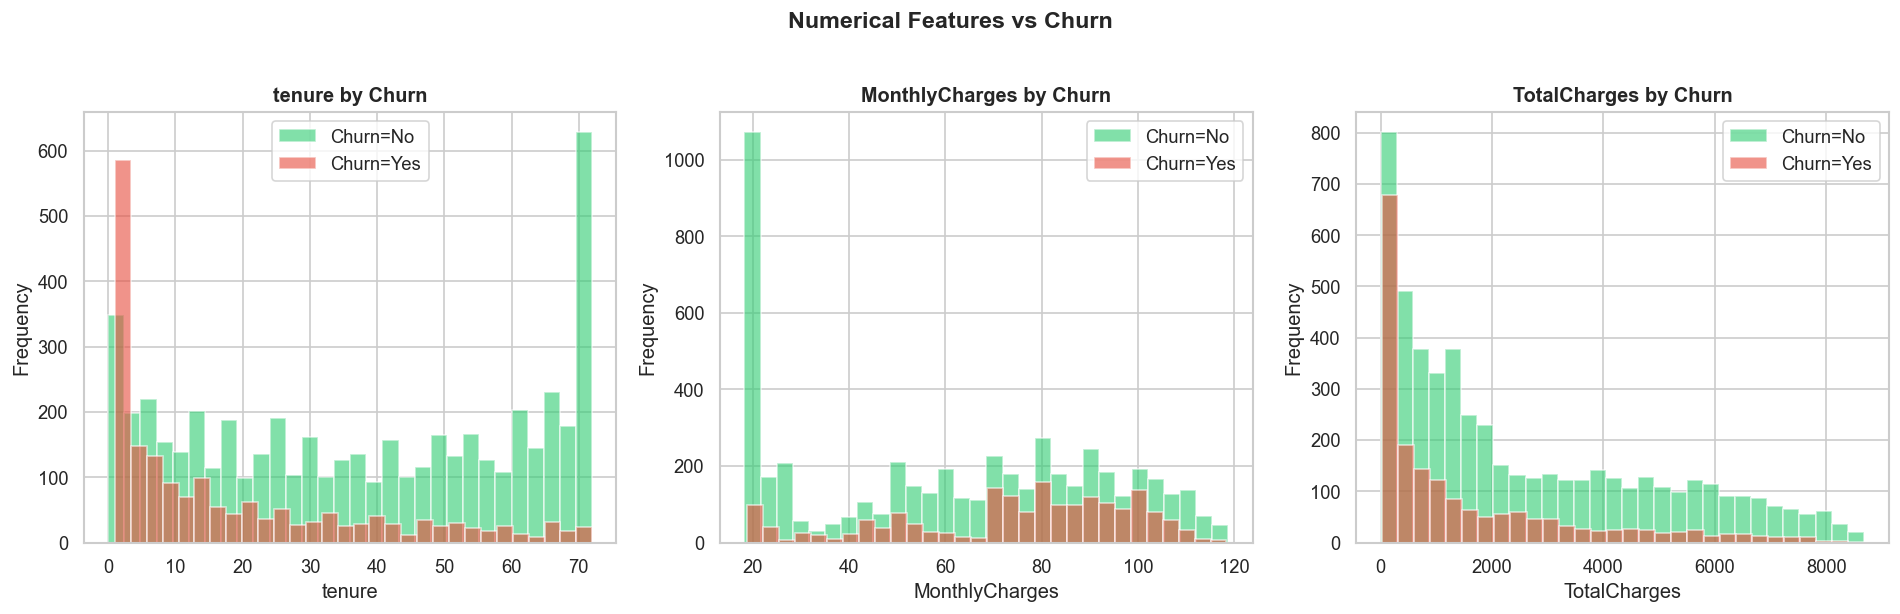

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(num_cols):
    for label, color in zip(['No', 'Yes'], ['#2ecc71', '#e74c3c']):
        axes[i].hist(df[df['Churn'] == label][col], bins=30,
                     alpha=0.6, label=f'Churn={label}', color=color, edgecolor='white')
    axes[i].set_title(f'{col} by Churn', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.suptitle('Numerical Features vs Churn', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

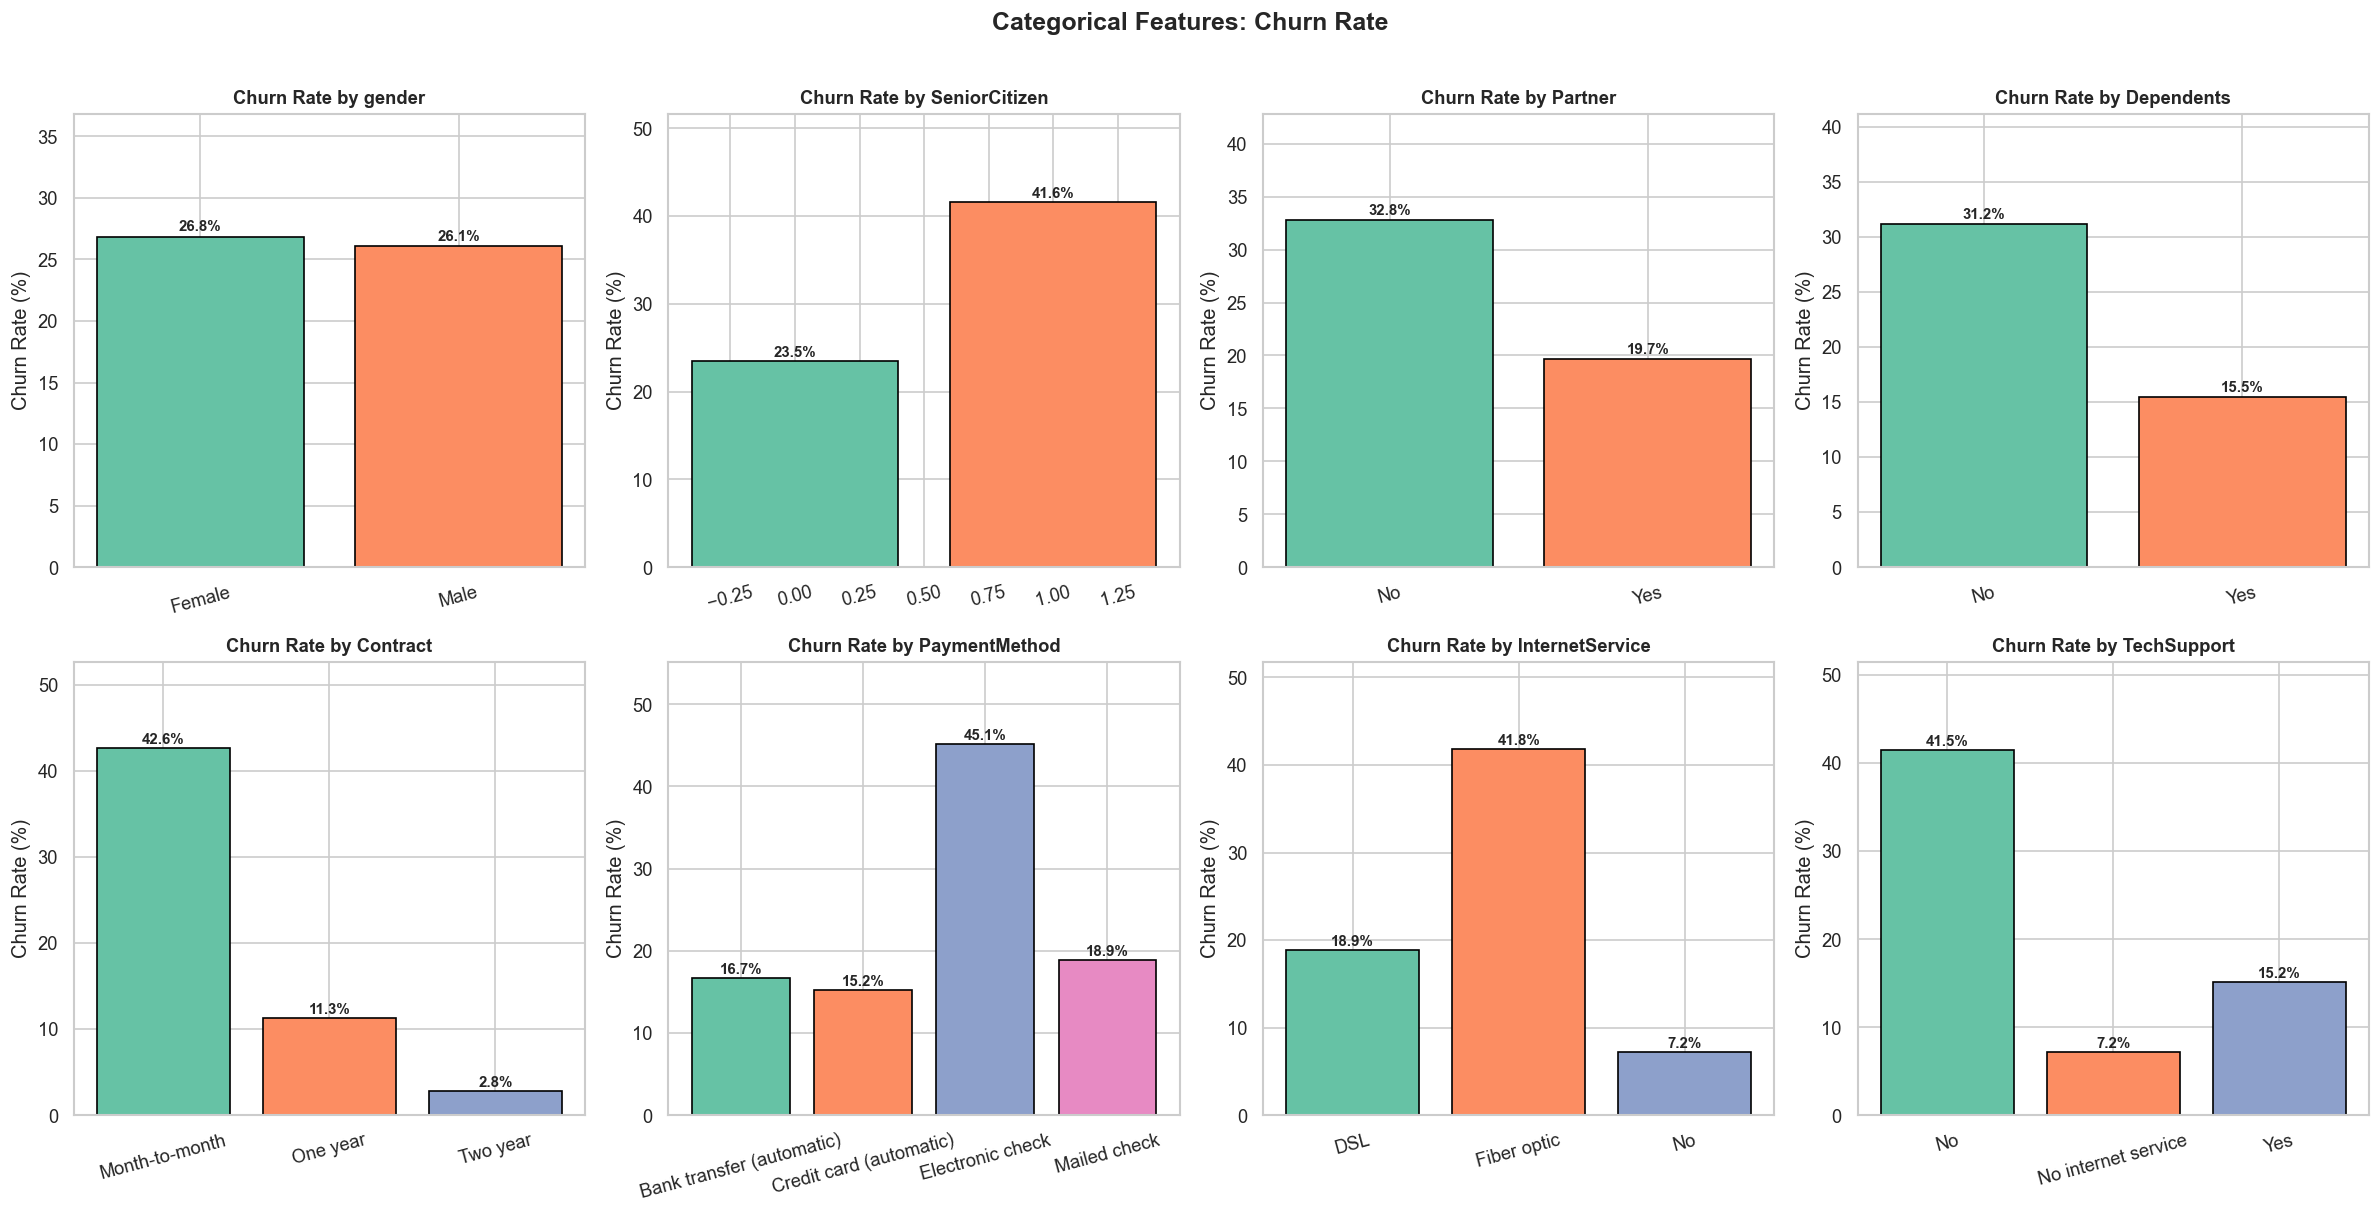

In [ ]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'Contract', 'PaymentMethod', 'InternetService', 'TechSupport']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    bars = axes[i].bar(churn_rate.index, churn_rate.values,
                       color=sns.color_palette('Set2', len(churn_rate)), edgecolor='black')
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].set_ylim(0, churn_rate.max() + 10)

plt.suptitle('Categorical Features: Churn Rate', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

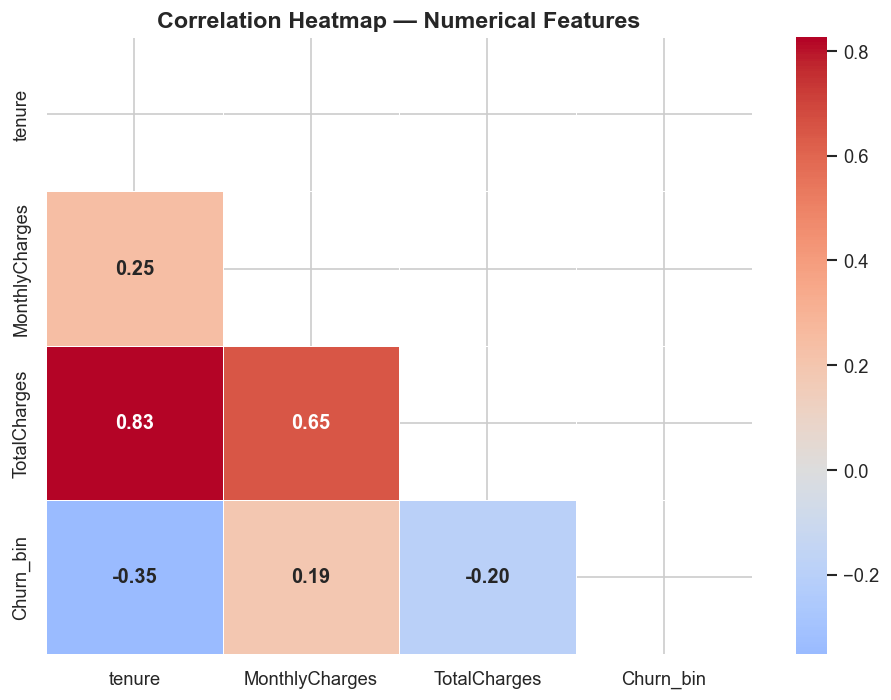

In [25]:
# Correlation heatmap
df_temp = df.copy()
df_temp['Churn_bin'] = (df_temp['Churn'] == 'Yes').astype(int)
corr = df_temp[num_cols + ['Churn_bin']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=ax, linewidths=0.5,
            annot_kws={'fontsize': 12, 'fontweight': 'bold'})
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

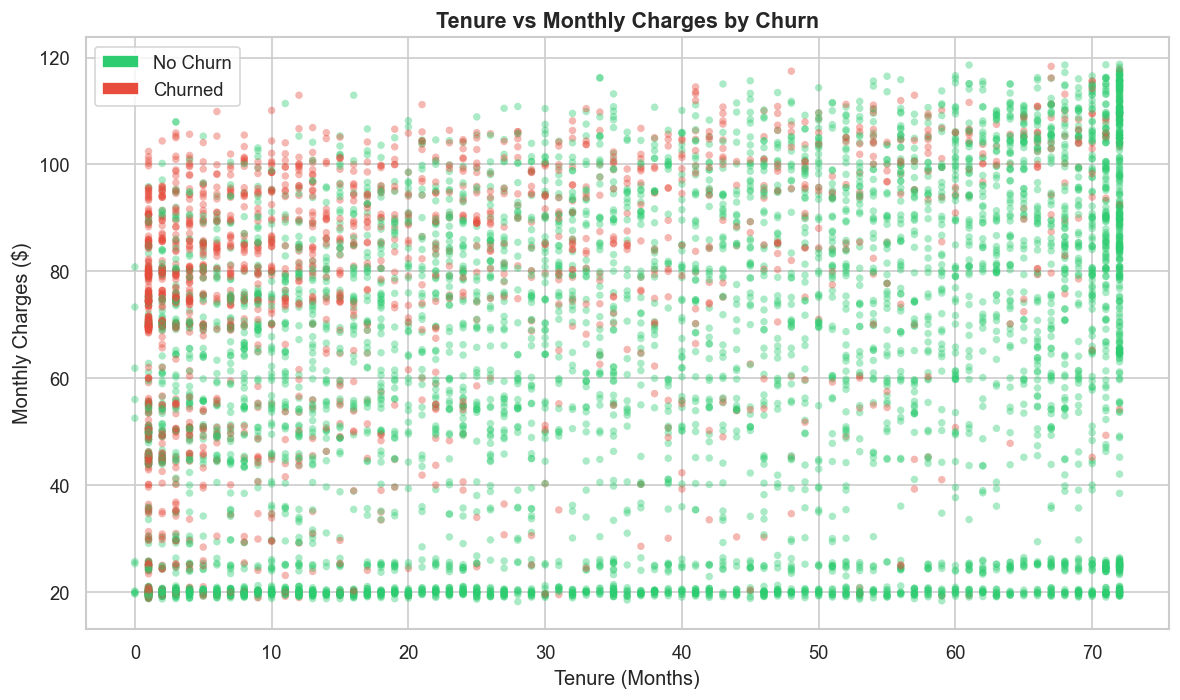

In [26]:
# Tenure vs Monthly Charges scatter
fig, ax = plt.subplots(figsize=(10, 6))
colors = df['Churn'].map({'No': '#2ecc71', 'Yes': '#e74c3c'})
ax.scatter(df['tenure'], df['MonthlyCharges'], c=colors, alpha=0.4, s=20, edgecolors='none')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#2ecc71', label='No Churn'),
                   Patch(facecolor='#e74c3c', label='Churned')], fontsize=11)
ax.set_xlabel('Tenure (Months)', fontsize=12)
ax.set_ylabel('Monthly Charges ($)', fontsize=12)
ax.set_title('Tenure vs Monthly Charges by Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
df_encoded = df.copy()

df_encoded['Churn'] = (df_encoded['Churn'] == 'Yes').astype(int)

#yes/no columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df_encoded[col] = (df_encoded[col] == 'Yes').astype(int)

df_encoded['gender'] = (df_encoded['gender'] == 'Male').astype(int)

# One-hot encode 
ohe_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaymentMethod']
df_encoded = pd.get_dummies(df_encoded, columns=ohe_cols, drop_first=True)

# Engineered feature
df_encoded['AvgMonthlySpend'] = df_encoded['TotalCharges'] / (df_encoded['tenure'] + 1)

print(f'Encoding complete. Shape: {df_encoded.shape}')
print(f'Total features: {df_encoded.shape[1] - 1}')
df_encoded.head(3)

Encoding complete. Shape: (7021, 32)
Total features: 31


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AvgMonthlySpend
0,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,14.925000
1,1,0,0,0,34,1,0,56.95,1889.50,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,53.985714
2,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,36.050000


Handle Class Imbalance — SMOTE

Before SMOTE — No Churn: 5,164 | Churn: 1,857
After SMOTE  — No Churn: 5,164 | Churn: 5,164


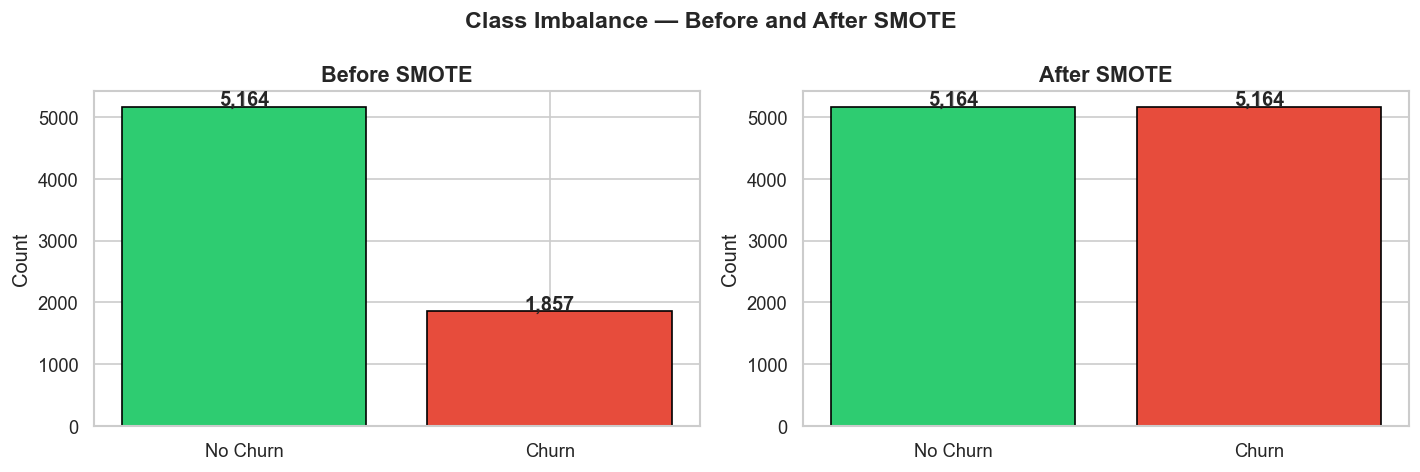

In [28]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f'Before SMOTE — No Churn: {(y==0).sum():,} | Churn: {(y==1).sum():,}')

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print(f'After SMOTE  — No Churn: {(y_resampled==0).sum():,} | Churn: {(y_resampled==1).sum():,}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (data, title) in zip(axes, [(y, 'Before SMOTE'), (y_resampled, 'After SMOTE')]):
    counts = data.value_counts()
    ax.bar(['No Churn', 'Churn'], counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
    for j, v in enumerate(counts.values):
        ax.text(j, v + 30, f'{v:,}', ha='center', fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_ylabel('Count')

plt.suptitle('Class Imbalance — Before and After SMOTE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

print(f'Training set : {X_train.shape[0]:,} samples')
print(f'Test set     : {X_test.shape[0]:,} samples')
print(f'Features     : {X_train.shape[1]}')
print(f'Train balance: {y_train.value_counts(normalize=True).to_dict()}')
print(f'Test balance : {y_test.value_counts(normalize=True).to_dict()}')

Training set : 8,262 samples
Test set     : 2,066 samples
Features     : 31
Train balance: {1: 0.5, 0: 0.5}
Test balance : {0: 0.5, 1: 0.5}



Baseline Models

Models: Logistic Regression, Decision Tree, AdaBoost

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
import time

 Evaluation Helper

In [31]:
all_results = []

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name='Model'):
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_prob  = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob) if y_prob is not None else None
    cv   = cross_val_score(model, X_train, y_train, cv=5, scoring='f1').mean()

    print(f'{'='*55}')
    print(f'  {model_name}')
    print(f'{'='*55}')
    print(f'  Accuracy       : {acc:.4f}')
    print(f'  Precision      : {prec:.4f}')
    print(f'  Recall         : {rec:.4f}')
    print(f'  F1-Score       : {f1:.4f}')
    if auc: print(f'  ROC-AUC        : {auc:.4f}')
    print(f'  CV F1 (5-fold) : {cv:.4f}')
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                           display_labels=['No Churn', 'Churn']).plot(
        ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title(f'{model_name} — Confusion Matrix', fontweight='bold')

    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc:.3f}')
        axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
        axes[1].fill_between(fpr, tpr, alpha=0.1, color='darkorange')
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title(f'{model_name} — ROC Curve', fontweight='bold')
        axes[1].legend(loc='lower right')

    plt.tight_layout()
    plt.show()

    return {'Model': model_name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc, 'CV_F1': cv}

print('Evaluation function ready.')

Evaluation function ready.


Logistic Regression

In [32]:
lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [200]
}
lr_grid = GridSearchCV(LogisticRegression(random_state=42),
                       lr_params, cv=5, scoring='f1', n_jobs=-1)
lr_grid.fit(X_train, y_train)
print(f'Best params : {lr_grid.best_params_}')
print(f'Best CV F1  : {lr_grid.best_score_:.4f}')

Best params : {'C': 100, 'max_iter': 200, 'solver': 'liblinear'}
Best CV F1  : 0.7926


  Logistic Regression
  Accuracy       : 0.7633
  Precision      : 0.7505
  Recall         : 0.7890
  F1-Score       : 0.7692
  ROC-AUC        : 0.8509
  CV F1 (5-fold) : 0.7926
              precision    recall  f1-score   support

    No Churn       0.78      0.74      0.76      1033
       Churn       0.75      0.79      0.77      1033

    accuracy                           0.76      2066
   macro avg       0.76      0.76      0.76      2066
weighted avg       0.76      0.76      0.76      2066



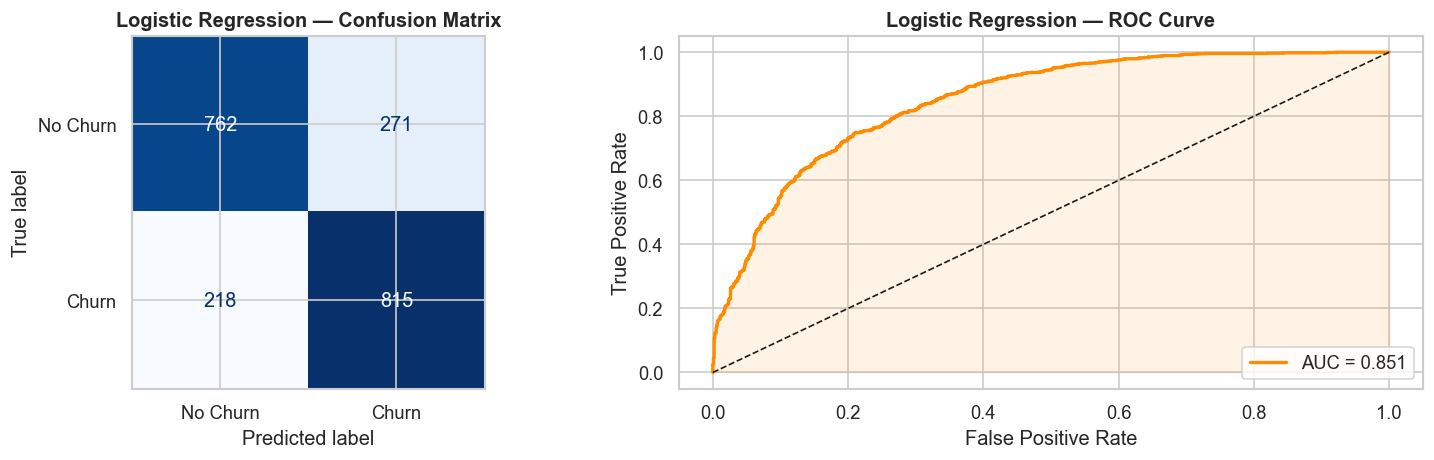

In [33]:
lr_best    = lr_grid.best_estimator_
lr_results = evaluate_model(lr_best, X_train, X_test, y_train, y_test,
                             model_name='Logistic Regression')
all_results.append(lr_results)

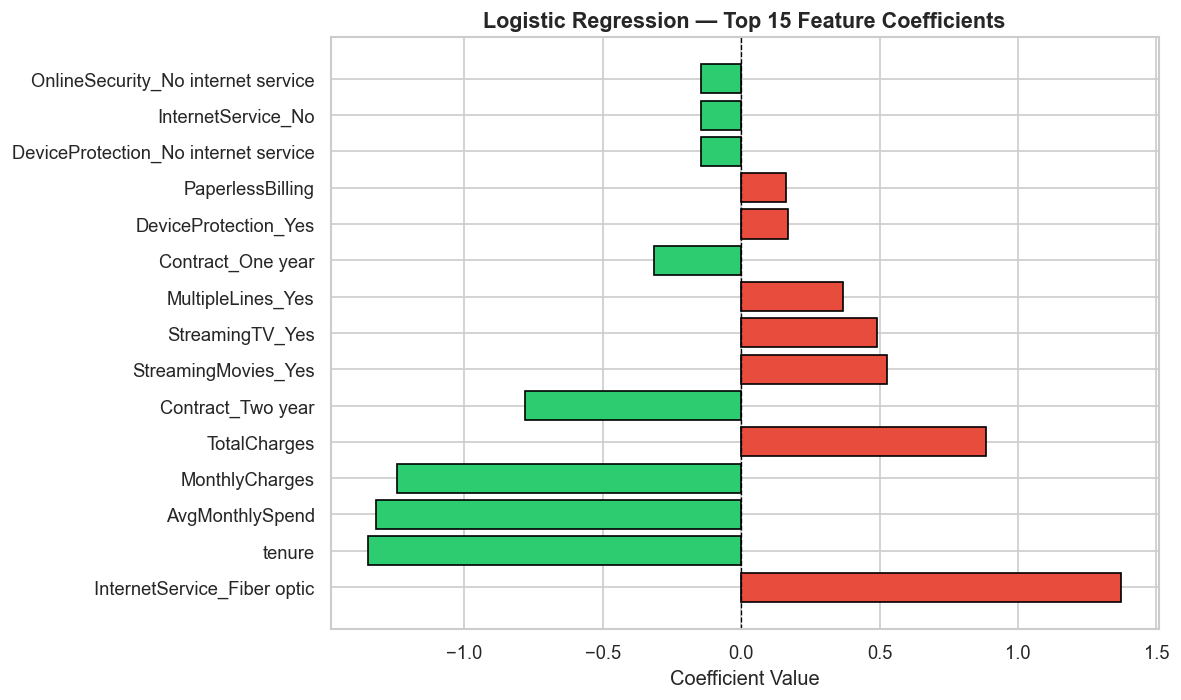

In [ ]:
coef_df = pd.DataFrame({'Feature': X_train.columns,
                         'Coefficient': lr_best.coef_[0]})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Logistic Regression — Top 15 Feature Coefficients', fontweight='bold', fontsize=13)
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

Decision Tree

In [35]:
dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       dt_params, cv=5, scoring='f1', n_jobs=-1)
dt_grid.fit(X_train, y_train)
print(f'Best params : {dt_grid.best_params_}')
print(f'Best CV F1  : {dt_grid.best_score_:.4f}')

Best params : {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best CV F1  : 0.8066


  Decision Tree
  Accuracy       : 0.8030
  Precision      : 0.7717
  Recall         : 0.8606
  F1-Score       : 0.8137
  ROC-AUC        : 0.8665
  CV F1 (5-fold) : 0.8066
              precision    recall  f1-score   support

    No Churn       0.84      0.75      0.79      1033
       Churn       0.77      0.86      0.81      1033

    accuracy                           0.80      2066
   macro avg       0.81      0.80      0.80      2066
weighted avg       0.81      0.80      0.80      2066



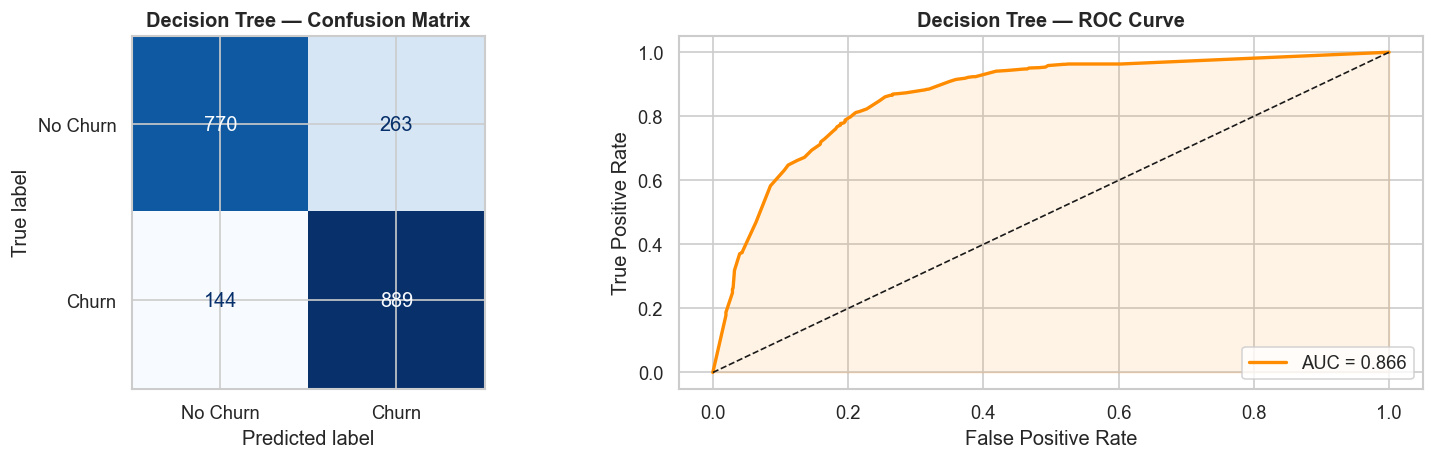

In [36]:
dt_best    = dt_grid.best_estimator_
dt_results = evaluate_model(dt_best, X_train, X_test, y_train, y_test,
                             model_name='Decision Tree')
all_results.append(dt_results)

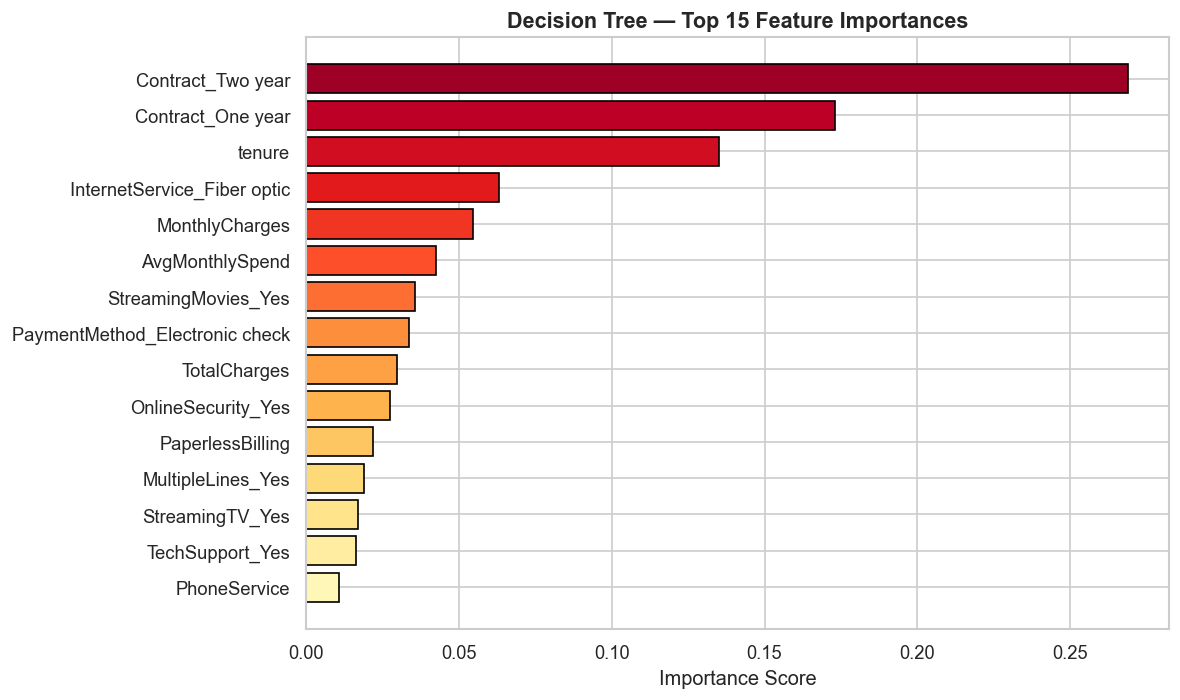

In [37]:
# Feature importance
fi_df = pd.DataFrame({'Feature': X_train.columns,
                       'Importance': dt_best.feature_importances_})\
          .sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(fi_df['Feature'], fi_df['Importance'],
        color=sns.color_palette('YlOrRd_r', 15), edgecolor='black')
ax.set_title('Decision Tree — Top 15 Feature Importances', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

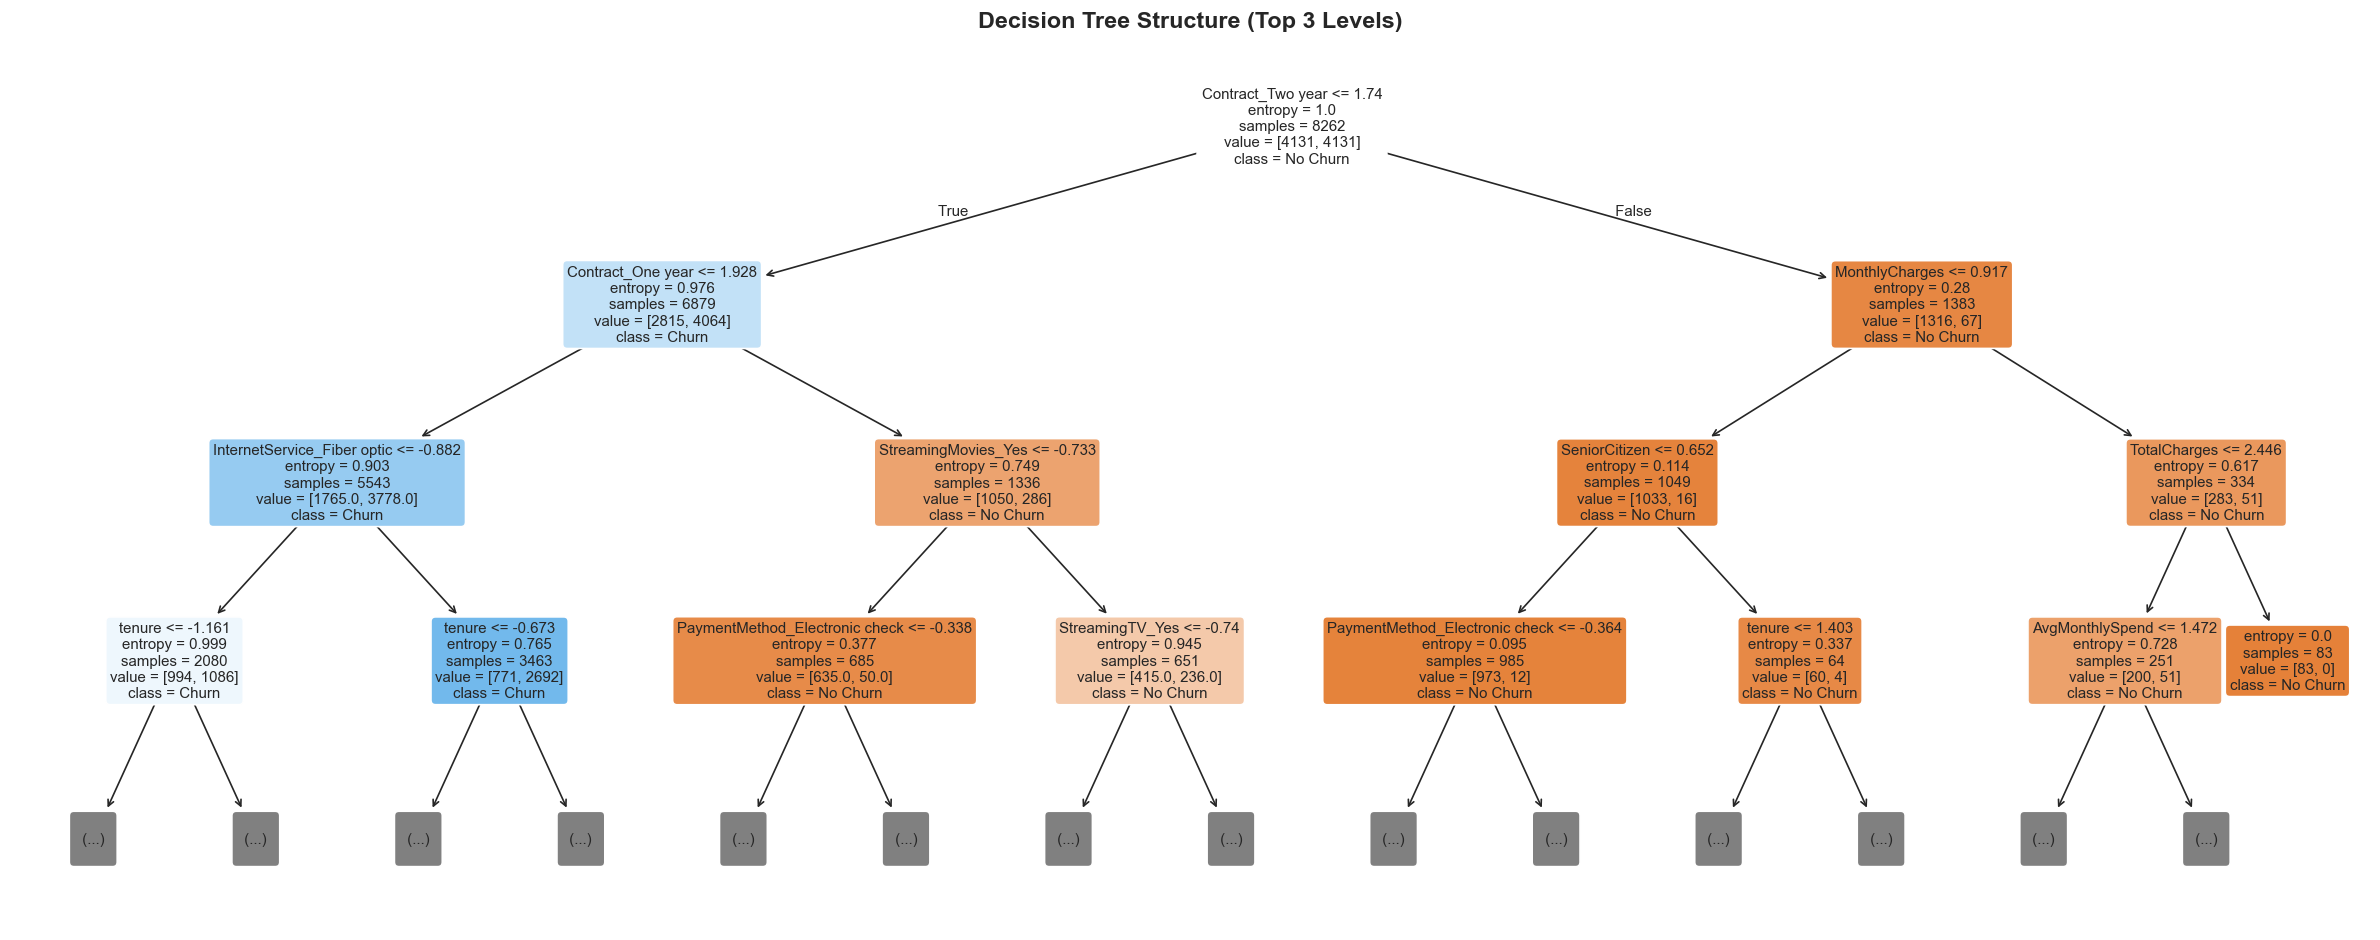

In [38]:
# Tree visualisation (top 3 levels)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt_best, max_depth=3, feature_names=X_train.columns,
          class_names=['No Churn', 'Churn'], filled=True,
          rounded=True, fontsize=9, ax=ax)
ax.set_title('Decision Tree Structure (Top 3 Levels)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


AdaBoost

In [40]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Parameter grid
ada_params = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
    'estimator': [
        DecisionTreeClassifier(max_depth=1),
        DecisionTreeClassifier(max_depth=2)
    ]
}

ada_grid = GridSearchCV(
    AdaBoostClassifier(random_state=42),
    ada_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Train
ada_grid.fit(X_train, y_train)

# Results
print(f'Best params : {ada_grid.best_params_}')
print(f'Best CV F1  : {ada_grid.best_score_:.4f}')

Best params : {'estimator': DecisionTreeClassifier(max_depth=2), 'learning_rate': 1.0, 'n_estimators': 300}
Best CV F1  : 0.8467


  AdaBoost
  Accuracy       : 0.8475
  Precision      : 0.8400
  Recall         : 0.8587
  F1-Score       : 0.8492
  ROC-AUC        : 0.9215
  CV F1 (5-fold) : 0.8467
              precision    recall  f1-score   support

    No Churn       0.86      0.84      0.85      1033
       Churn       0.84      0.86      0.85      1033

    accuracy                           0.85      2066
   macro avg       0.85      0.85      0.85      2066
weighted avg       0.85      0.85      0.85      2066



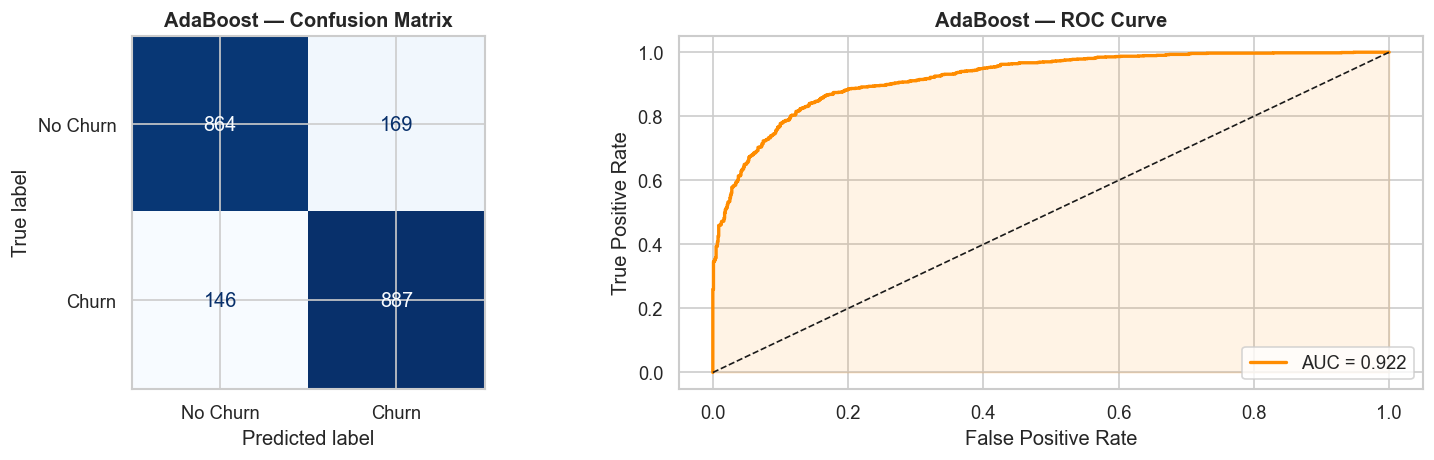

In [41]:
ada_best    = ada_grid.best_estimator_
ada_results = evaluate_model(ada_best, X_train, X_test, y_train, y_test,
                              model_name='AdaBoost')
all_results.append(ada_results)

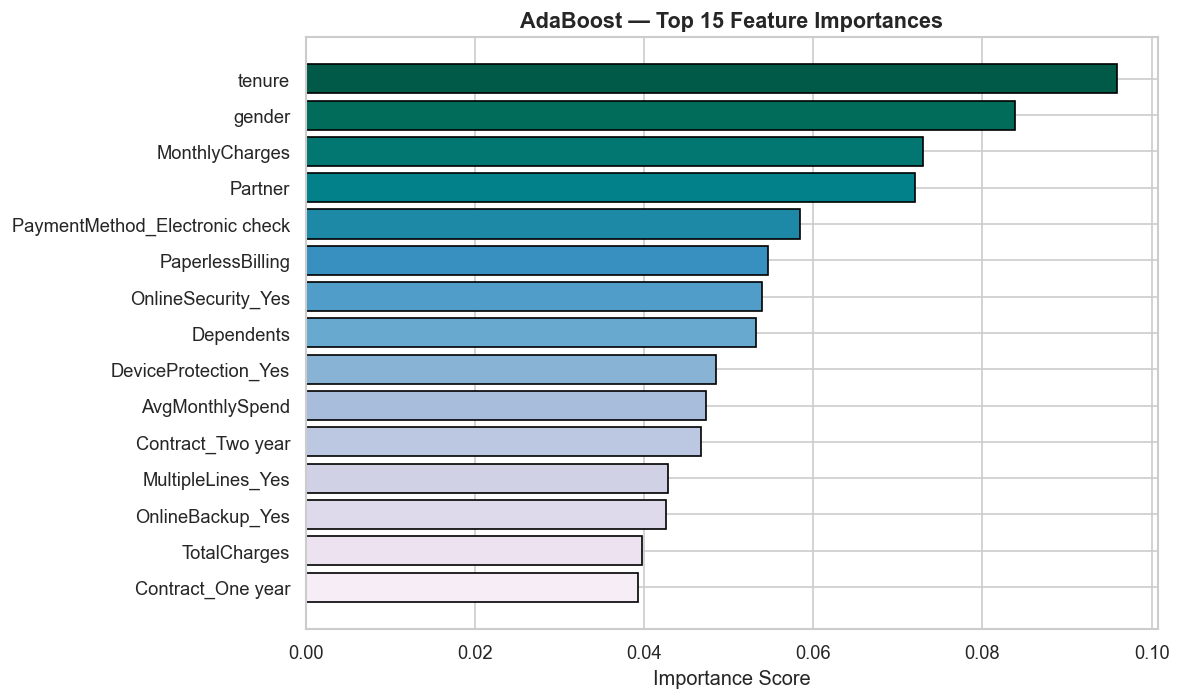

In [42]:
# AdaBoost feature importance
ada_fi = pd.DataFrame({'Feature': X_train.columns,
                        'Importance': ada_best.feature_importances_})\
           .sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(ada_fi['Feature'], ada_fi['Importance'],
        color=sns.color_palette('PuBuGn_r', 15), edgecolor='black')
ax.set_title('AdaBoost — Top 15 Feature Importances', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


Baseline Model Comparison

In [43]:
baseline_df = pd.DataFrame(all_results).set_index('Model')
print('=== Baseline Model Comparison ===')
print(baseline_df.to_string())
baseline_df

=== Baseline Model Comparison ===
                     Accuracy  Precision    Recall  F1-Score   ROC-AUC     CV_F1
Model                                                                           
Logistic Regression  0.763311   0.750460  0.788964  0.769231  0.850855  0.792620
Decision Tree        0.803001   0.771701  0.860600  0.813730  0.866496  0.806555
AdaBoost             0.847531   0.839962  0.858664  0.849210  0.921503  0.846704


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV_F1
Model,,,,,,
Logistic Regression,0.763311,0.750460,0.788964,0.769231,0.850855,0.792620
Decision Tree,0.803001,0.771701,0.860600,0.813730,0.866496,0.806555
AdaBoost,0.847531,0.839962,0.858664,0.849210,0.921503,0.846704


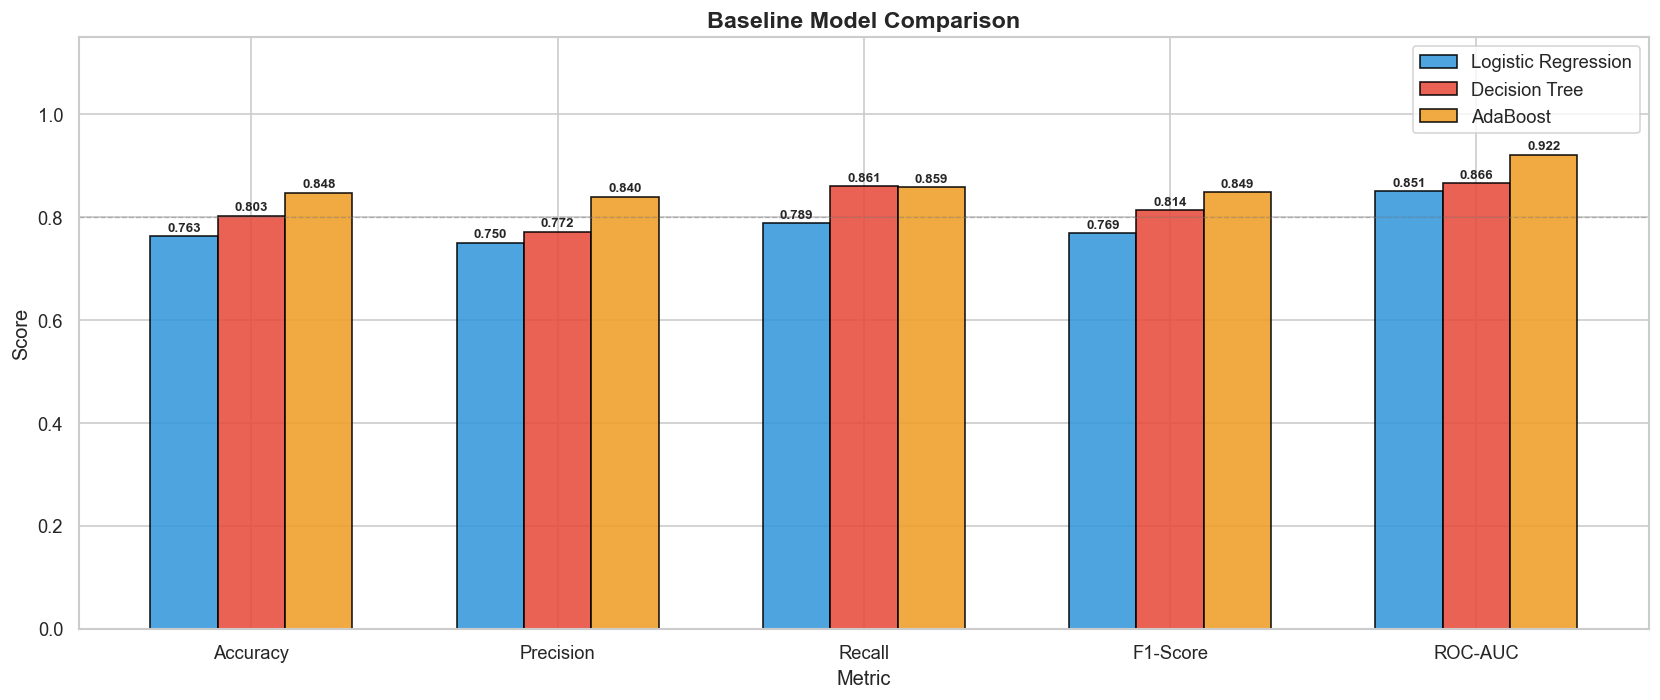

Best baseline model by F1: AdaBoost


In [44]:
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x           = np.arange(len(metrics))
width       = 0.22
colors_list = ['#3498db', '#e74c3c', '#EF9F27']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (model_name, row) in enumerate(baseline_df.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=model_name,
                  color=colors_list[i], edgecolor='black', alpha=0.88)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Baseline Model Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

best_baseline = baseline_df['F1-Score'].idxmax()
print(f'Best baseline model by F1: {best_baseline}')


Models: Random Forest, XGBoost

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

advanced_results = []


Random Forest

In [47]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced']
}
rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, n_iter=30, cv=5, scoring='f1', n_jobs=-1, random_state=42
)
rf_random.fit(X_train, y_train)
print(f'Best params : {rf_random.best_params_}')
print(f'Best CV F1  : {rf_random.best_score_:.4f}')

Best params : {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30, 'class_weight': 'balanced'}
Best CV F1  : 0.8472


  Random Forest
  Accuracy       : 0.8480
  Precision      : 0.8453
  Recall         : 0.8519
  F1-Score       : 0.8486
  ROC-AUC        : 0.9236
  CV F1 (5-fold) : 0.8472
              precision    recall  f1-score   support

    No Churn       0.85      0.84      0.85      1033
       Churn       0.85      0.85      0.85      1033

    accuracy                           0.85      2066
   macro avg       0.85      0.85      0.85      2066
weighted avg       0.85      0.85      0.85      2066



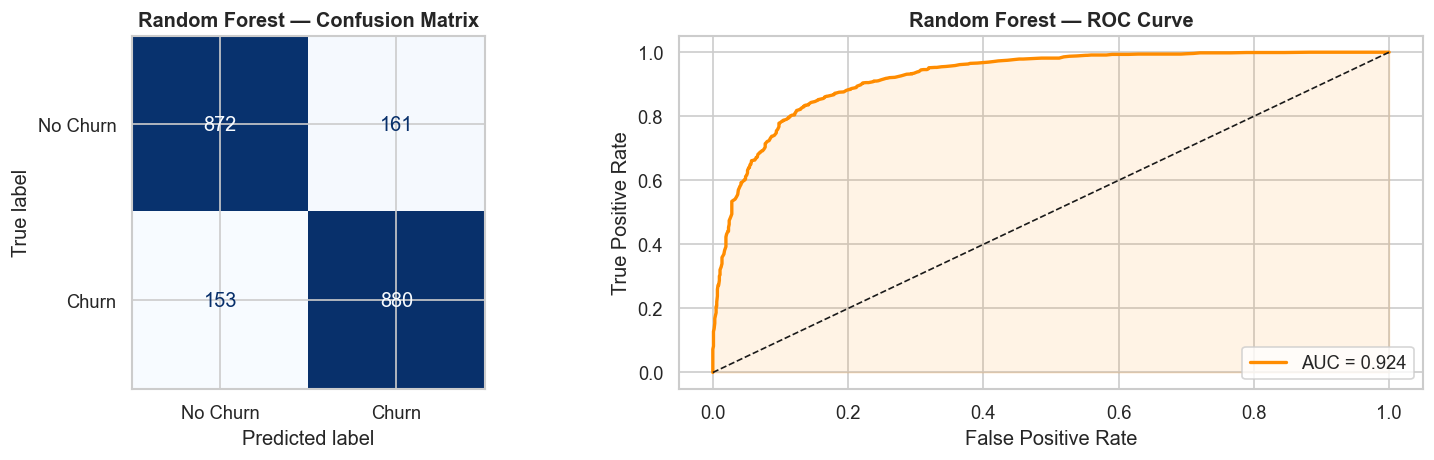

In [48]:
rf_best    = rf_random.best_estimator_
rf_results = evaluate_model(rf_best, X_train, X_test, y_train, y_test,
                             model_name='Random Forest')
advanced_results.append(rf_results)

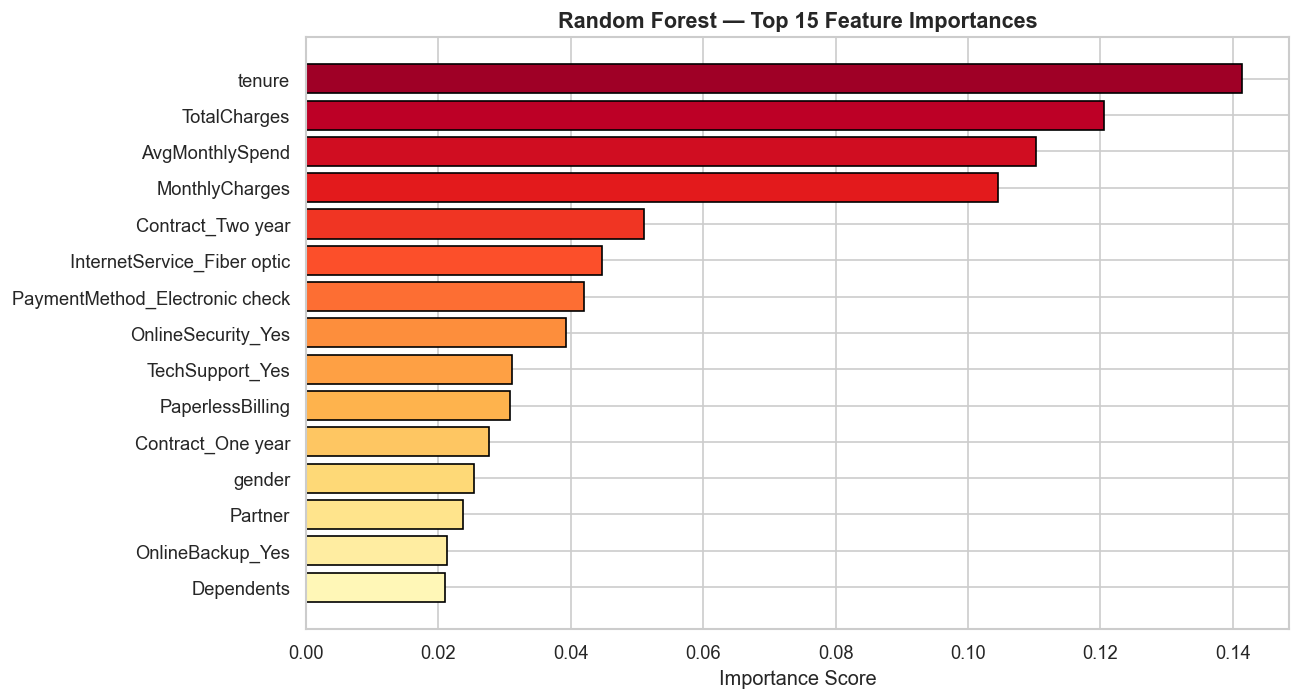

Top 5 features:
  tenure                                   0.1414
  TotalCharges                             0.1206
  AvgMonthlySpend                          0.1103
  MonthlyCharges                           0.1045
  Contract_Two year                        0.0511


In [49]:
# Feature importance
rf_fi = pd.DataFrame({'Feature': X_train.columns,
                       'Importance': rf_best.feature_importances_})\
          .sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(rf_fi['Feature'], rf_fi['Importance'],
        color=sns.color_palette('YlOrRd_r', 15), edgecolor='black')
ax.set_title('Random Forest — Top 15 Feature Importances', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 5 features:')
for _, row in rf_fi.head(5).iterrows():
    print(f'  {row["Feature"]:40s} {row["Importance"]:.4f}')


 XGBoost

In [50]:
xgb_params = {
    'n_estimators': [300, 500, 700, 1000],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.005, 0.01, 0.05, 0.1],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.5, 0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.01, 0.1, 0.5, 1],
    'reg_lambda': [0.5, 1, 1.5, 2, 3]
}
xgb_random = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
    xgb_params, n_iter=100, cv=5, scoring='f1', n_jobs=-1, random_state=42
)
xgb_random.fit(X_train, y_train)
print(f'Best params : {xgb_random.best_params_}')
print(f'Best CV F1  : {xgb_random.best_score_:.4f}')

Best params : {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.5}
Best CV F1  : 0.8573


  XGBoost
  Accuracy       : 0.8504
  Precision      : 0.8467
  Recall         : 0.8558
  F1-Score       : 0.8512
  ROC-AUC        : 0.9319
  CV F1 (5-fold) : 0.8579
              precision    recall  f1-score   support

    No Churn       0.85      0.85      0.85      1033
       Churn       0.85      0.86      0.85      1033

    accuracy                           0.85      2066
   macro avg       0.85      0.85      0.85      2066
weighted avg       0.85      0.85      0.85      2066



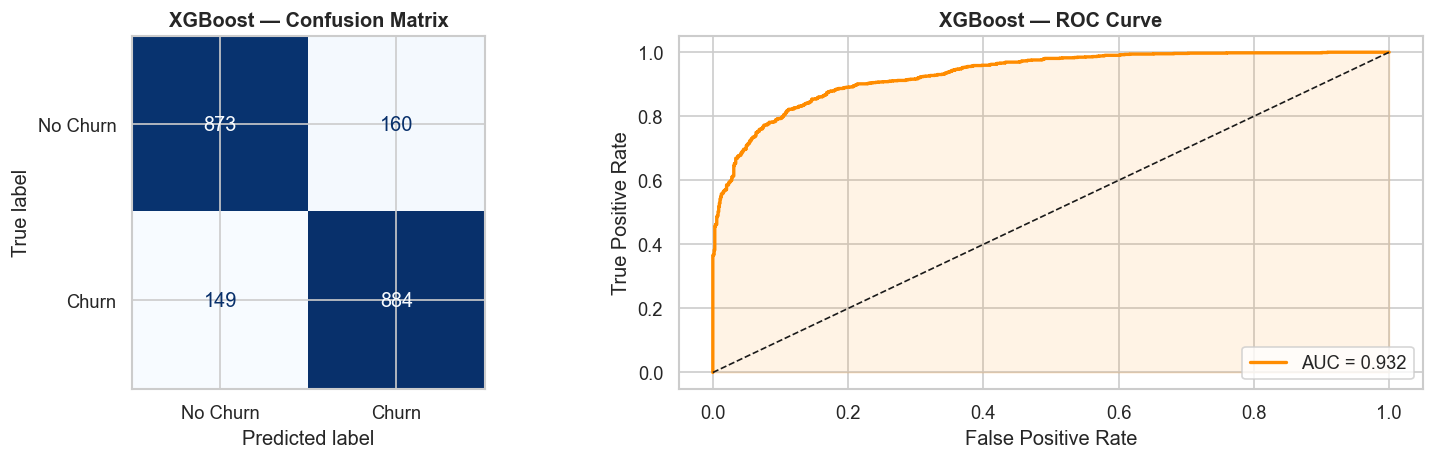

In [51]:
xgb_best    = xgb_random.best_estimator_
xgb_results = evaluate_model(xgb_best, X_train, X_test, y_train, y_test,
                              model_name='XGBoost')
advanced_results.append(xgb_results)

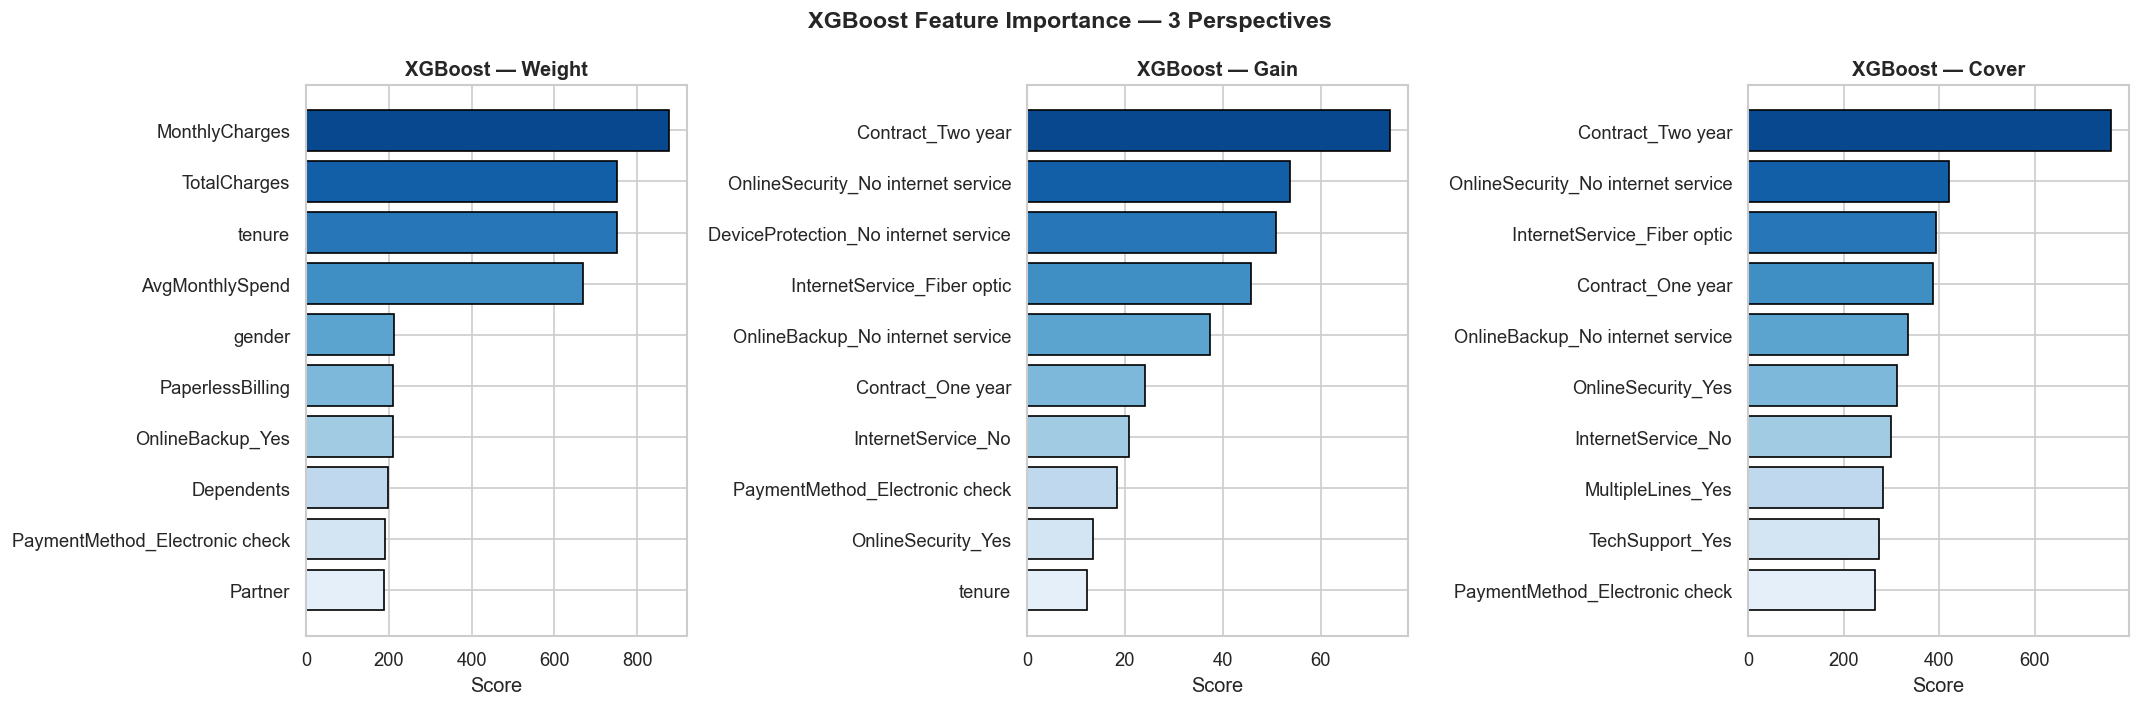

In [52]:
# XGBoost feature importance — 3 perspectives
importance_types = ['weight', 'gain', 'cover']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, imp_type in zip(axes, importance_types):
    scores = xgb_best.get_booster().get_score(importance_type=imp_type)
    fi_df  = pd.DataFrame(list(scores.items()), columns=['Feature', 'Score'])\
               .sort_values('Score', ascending=False).head(10)
    ax.barh(fi_df['Feature'], fi_df['Score'],
            color=sns.color_palette('Blues_r', 10), edgecolor='black')
    ax.set_title(f'XGBoost — {imp_type.capitalize()}', fontweight='bold')
    ax.set_xlabel('Score')
    ax.invert_yaxis()

plt.suptitle('XGBoost Feature Importance — 3 Perspectives', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Default threshold (0.50) F1 : 0.8512
Best threshold    (0.44) F1 : 0.8561


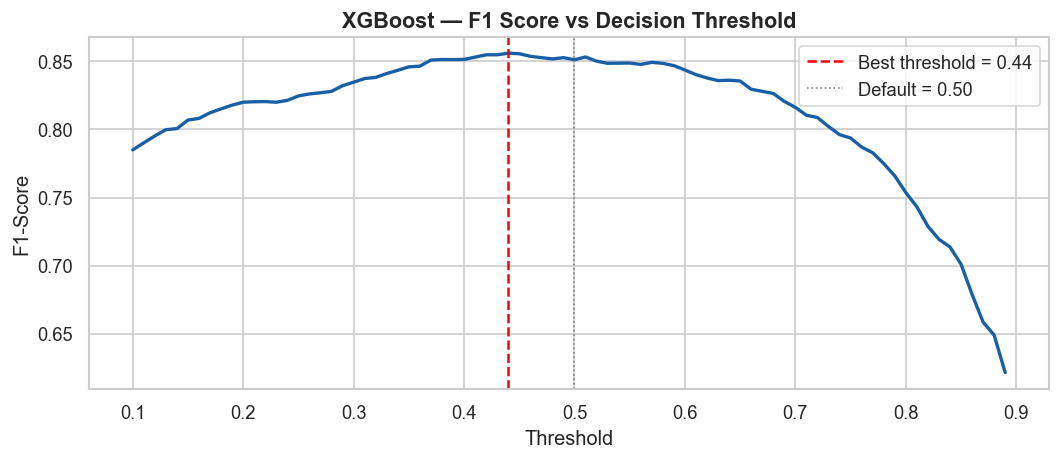

In [53]:
# Threshold tuning for XGBoost
from sklearn.metrics import f1_score as f1

y_prob_xgb    = xgb_best.predict_proba(X_test)[:, 1]
thresholds    = np.arange(0.1, 0.9, 0.01)
f1_scores     = [f1(y_test, (y_prob_xgb >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]

print(f'Default threshold (0.50) F1 : {f1(y_test, (y_prob_xgb >= 0.5).astype(int)):.4f}')
print(f'Best threshold    ({best_threshold:.2f}) F1 : {max(f1_scores):.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, f1_scores, color='#185FA5', lw=2)
ax.axvline(best_threshold, color='red', linestyle='--', linewidth=1.5,
           label=f'Best threshold = {best_threshold:.2f}')
ax.axvline(0.5, color='gray', linestyle=':', linewidth=1, label='Default = 0.50')
ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('XGBoost — F1 Score vs Decision Threshold', fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

 Cross-Validation Comparison

Random Forest         mean=0.8472  std=0.0051
XGBoost               mean=0.8579  std=0.0067


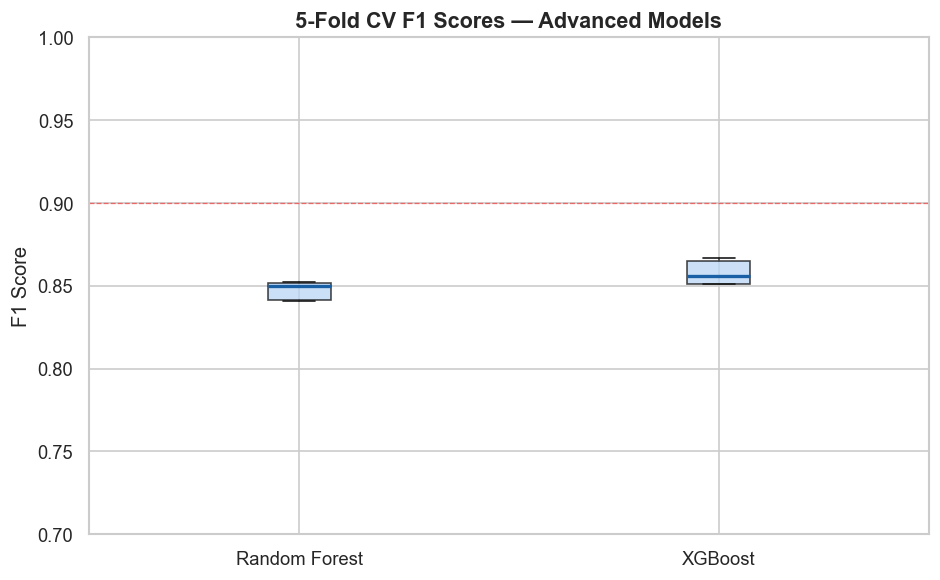

In [54]:
m3_models = {'Random Forest': rf_best, 'XGBoost': xgb_best}

cv_results = {}
for name, model in m3_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    cv_results[name] = scores
    print(f'{name:20s}  mean={scores.mean():.4f}  std={scores.std():.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
pd.DataFrame(cv_results).boxplot(ax=ax, patch_artist=True,
    boxprops=dict(facecolor='#B5D4F4', alpha=0.7),
    medianprops=dict(color='#185FA5', linewidth=2))
ax.set_title('5-Fold CV F1 Scores — Advanced Models', fontweight='bold', fontsize=13)
ax.set_ylabel('F1 Score')
ax.set_ylim(0.7, 1.0)
ax.axhline(0.9, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

Full Model Comparison

In [55]:
# Combine baseline + advanced results
full_results_df = pd.DataFrame(all_results + advanced_results).set_index('Model')
print('=== Full Model Comparison ===')
print(full_results_df.to_string())
full_results_df

=== Full Model Comparison ===
                     Accuracy  Precision    Recall  F1-Score   ROC-AUC     CV_F1
Model                                                                           
Logistic Regression  0.763311   0.750460  0.788964  0.769231  0.850855  0.792620
Decision Tree        0.803001   0.771701  0.860600  0.813730  0.866496  0.806555
AdaBoost             0.847531   0.839962  0.858664  0.849210  0.921503  0.846704
Random Forest        0.848015   0.845341  0.851888  0.848602  0.923568  0.847171
XGBoost              0.850436   0.846743  0.855760  0.851228  0.931894  0.857896


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV_F1
Model,,,,,,
Logistic Regression,0.763311,0.750460,0.788964,0.769231,0.850855,0.792620
Decision Tree,0.803001,0.771701,0.860600,0.813730,0.866496,0.806555
AdaBoost,0.847531,0.839962,0.858664,0.849210,0.921503,0.846704
Random Forest,0.848015,0.845341,0.851888,0.848602,0.923568,0.847171
XGBoost,0.850436,0.846743,0.855760,0.851228,0.931894,0.857896


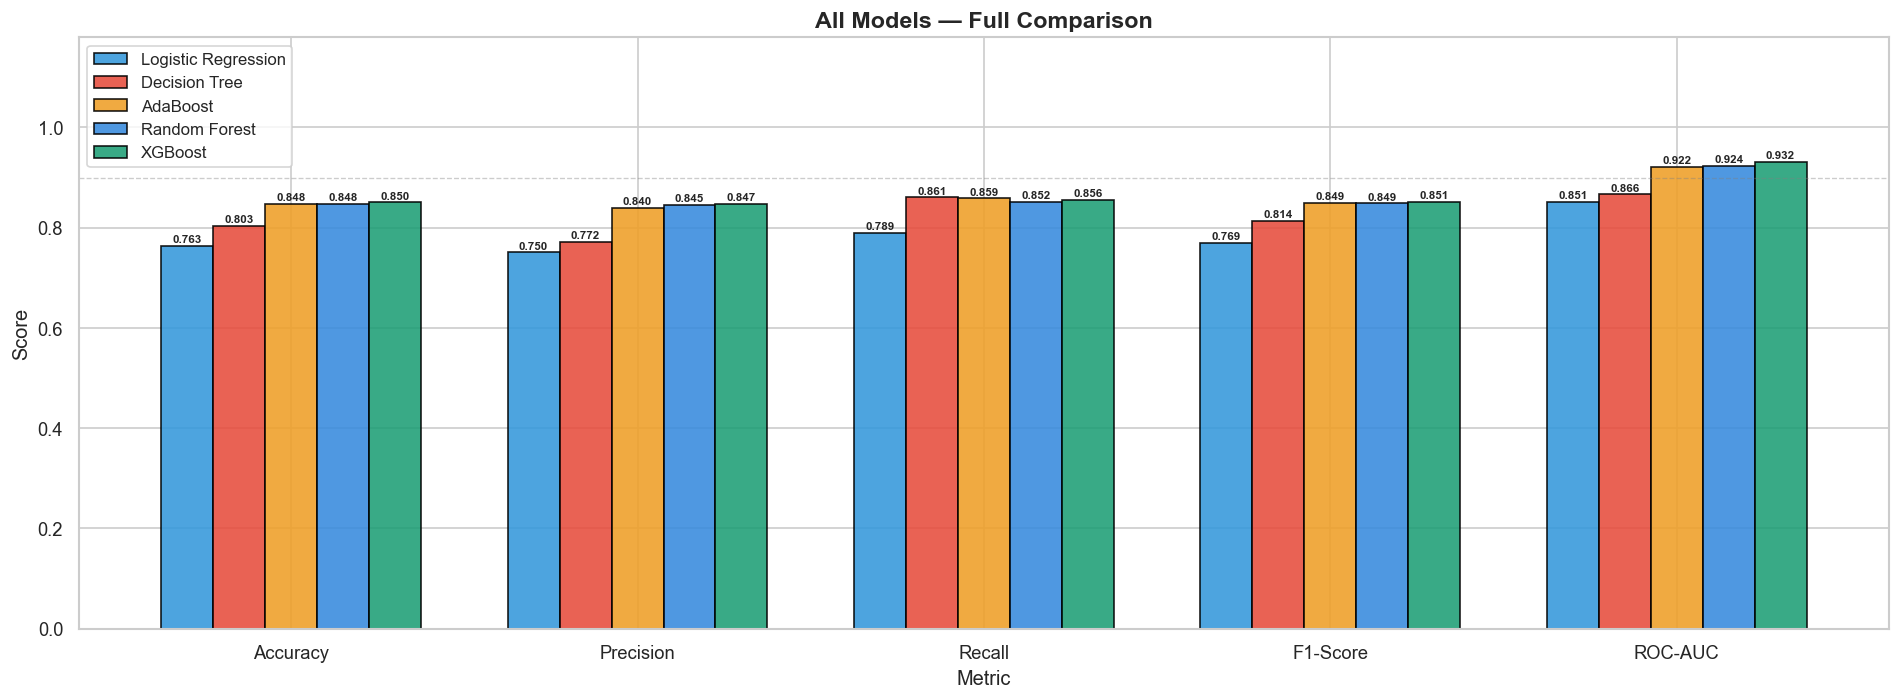

In [56]:
# Grouped bar chart — all 5 models
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x           = np.arange(len(metrics))
width       = 0.15
colors_list = ['#3498db', '#e74c3c', '#EF9F27', '#378ADD', '#1D9E75']

fig, ax = plt.subplots(figsize=(16, 6))
for i, (model_name, row) in enumerate(full_results_df.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=model_name,
                  color=colors_list[i], edgecolor='black', alpha=0.88)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('All Models — Full Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.18)
ax.legend(fontsize=10)
ax.axhline(0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.4)
plt.tight_layout()
plt.show()

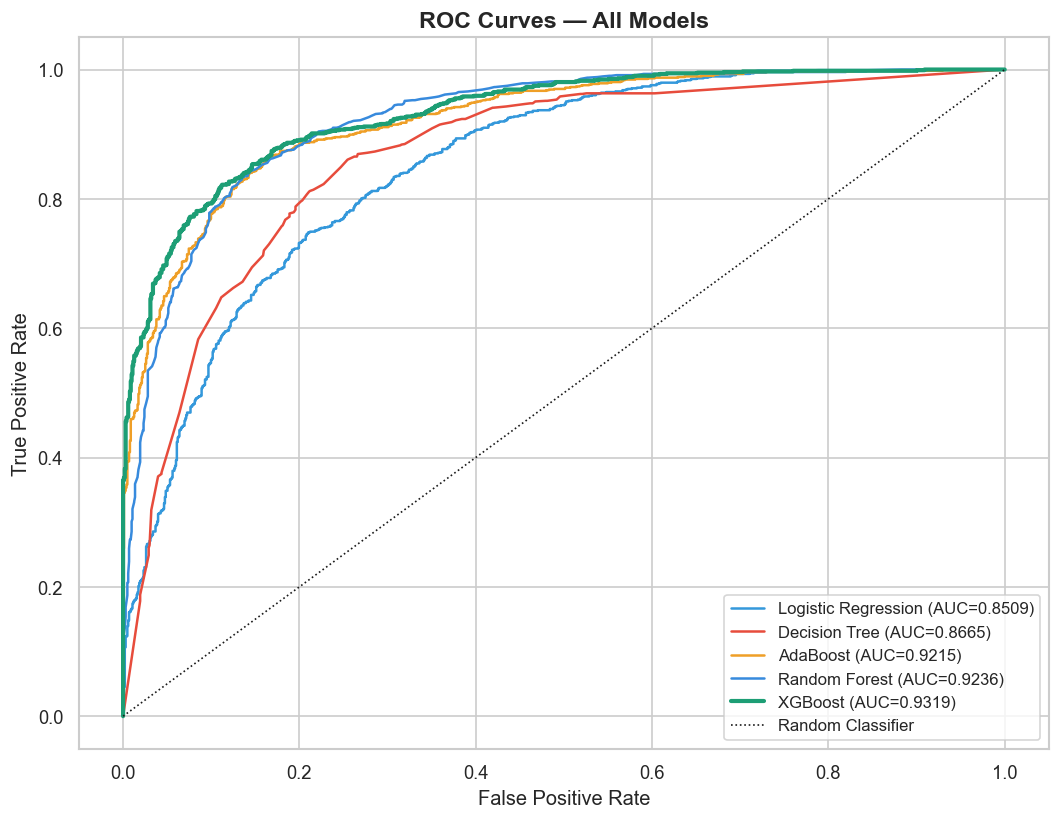

In [57]:
# ROC curves — all models on one plot
all_models = {
    'Logistic Regression': lr_best,
    'Decision Tree':       dt_best,
    'AdaBoost':            ada_best,
    'Random Forest':       rf_best,
    'XGBoost':             xgb_best
}
plot_colors = ['#3498db', '#e74c3c', '#EF9F27', '#378ADD', '#1D9E75']

fig, ax = plt.subplots(figsize=(9, 7))
for (name, model), color in zip(all_models.items(), plot_colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    lw  = 2.5 if name == 'XGBoost' else 1.5
    ax.plot(fpr, tpr, lw=lw, color=color, label=f'{name} (AUC={auc:.4f})')

ax.plot([0, 1], [0, 1], 'k:', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

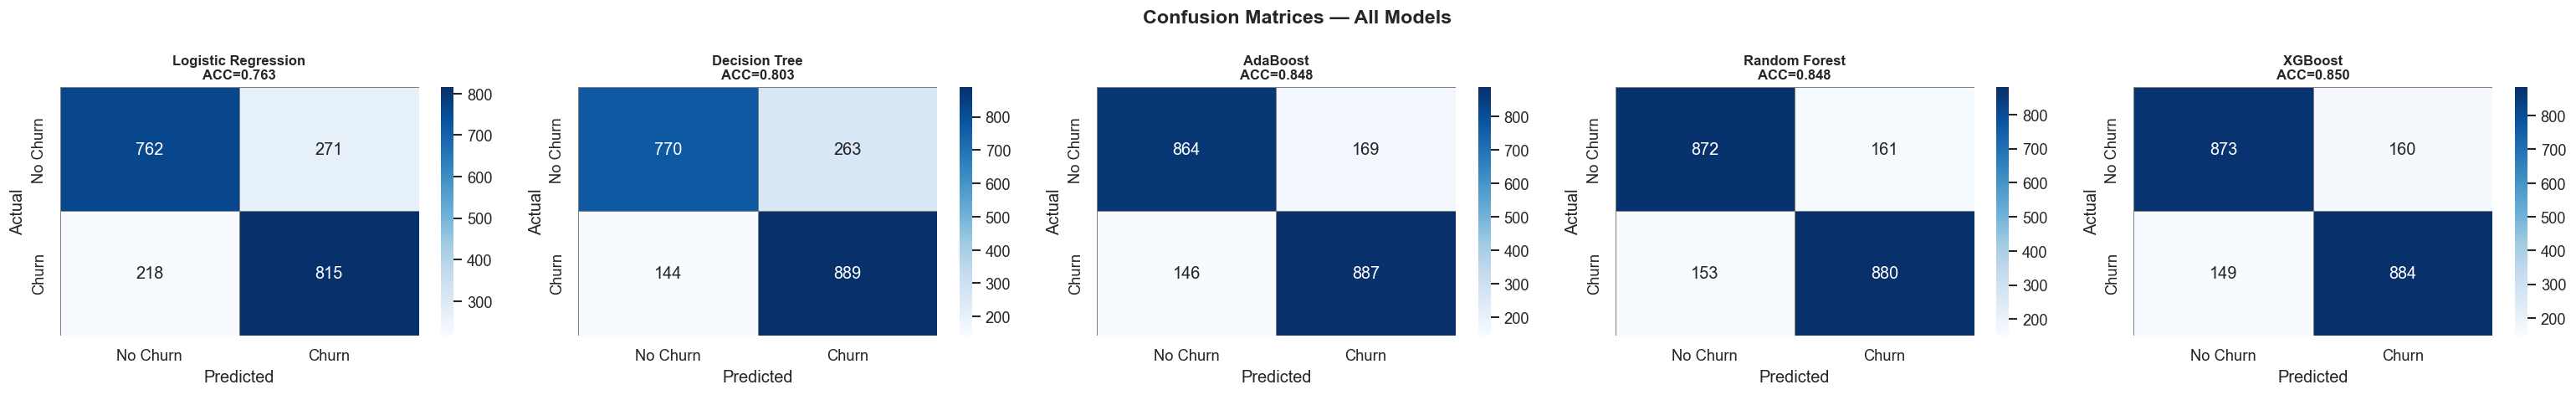

In [58]:
# Confusion matrices — all models
fig, axes = plt.subplots(1, 5, figsize=(26, 4))
for ax, (name, model) in zip(axes, all_models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'],
                linewidths=0.5, linecolor='gray')
    acc = accuracy_score(y_test, model.predict(X_test))
    ax.set_title(f'{name}\nACC={acc:.3f}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

 Final Model Selection

In [59]:
import joblib

best_model_name = full_results_df['F1-Score'].idxmax()
best_model_obj  = all_models[best_model_name]
best_row        = full_results_df.loc[best_model_name]

print('=' * 55)
print(f'  SELECTED FINAL MODEL: {best_model_name}')
print('=' * 55)
print(f'  Accuracy   : {best_row["Accuracy"]:.4f}')
print(f'  Precision  : {best_row["Precision"]:.4f}')
print(f'  Recall     : {best_row["Recall"]:.4f}')
print(f'  F1-Score   : {best_row["F1-Score"]:.4f}')
print(f'  ROC-AUC    : {best_row["ROC-AUC"]:.4f}')
print(f'  CV F1      : {best_row["CV_F1"]:.4f}')



  SELECTED FINAL MODEL: XGBoost
  Accuracy   : 0.8504
  Precision  : 0.8467
  Recall     : 0.8558
  F1-Score   : 0.8512
  ROC-AUC    : 0.9319
  CV F1      : 0.8579
